In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from shapely.geometry import LineString
import datetime
import time
import os

In [2]:
import matplotlib.animation as animation
print(animation.writers.list())


['pillow', 'ffmpeg', 'ffmpeg_file', 'html']


In [3]:
os.environ["PATH"] += os.pathsep + r"C:\Users\isamu\ffmpeg"  # Update this path as needed


### read files

In [4]:
pres = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/pressure_tourism_new.csv", index_col = 0)

In [64]:
df = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_from_hotel_full.csv")

In [6]:
# Create a new column 'movement_line' containing the LineString connecting the two points.
df['movement_line'] = df.apply(
    lambda row: LineString([
        (row['longitude_hotel'], row['latitude_hotel']),
        (row['longitude_visited'], row['latitude_visited'])
    ]),
    axis=1
)

In [9]:
df

,place_id_hotel,place_name_hotel,reviewer_profile,main_category_hotel,latitude_hotel,longitude_hotel,Buurt_hotel,Wijk_hotel,year,month,place_id_visited,place_name_visited,main_category_visited,latitude_visited,longitude_visited,Buurt_visited,Wijk_visited,movement_line
0,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,113987166664752762552,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJKYyxKekJxkcRLAhtiEY8skw,Paradiso,Locatie voor live muziek,52.362162,4.883806,Leidsebuurt-Zuidoost,De Weteringschans,"LINESTRING (4.8842114 52.369359, 4.8838059 52...."
1,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,111451103947221399197,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJg8bf-sIJxkcR9mc7li6y48E,Restaurant Vinkeles,Haute-cuisinerestaurant,52.369279,4.884023,Felix Meritisbuurt,Grachtengordel-West,"LINESTRING (4.8842114 52.369359, 4.884023 52.3..."
2,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103465487052100699800,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJg8bf-sIJxkcR9mc7li6y48E,Restaurant Vinkeles,Haute-cuisinerestaurant,52.369279,4.884023,Felix Meritisbuurt,Grachtengordel-West,"LINESTRING (4.8842114 52.369359, 4.884023 52.3..."
3,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJd_yDtNAJxkcRko3UnBeygWA,Chun Cafe Berenstraat,Broodjeswinkel,52.370469,4.883942,Felix Meritisbuurt,Grachtengordel-West,"LINESTRING (4.8842114 52.369359, 4.8839422 52...."
4,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Snackbar,52.368827,4.884062,Leidsegracht-Noord,Grachtengordel-West,"LINESTRING (4.8842114 52.369359, 4.8840617 52...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881551,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJX1rTlu8JxkcRGsV8-a4oKMI,Van Gogh Museum,Kunstmuseum,52.358076,4.881205,Museumplein,Museumkwartier,"LINESTRING (4.824796699999999 52.3417663, 4.88..."
881552,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJKzDpZ-UJxkcR6tvKHK2aPOw,Stedelijk Museum Amsterdam,Kunstmuseum,52.358011,4.879755,Museumplein,Museumkwartier,"LINESTRING (4.824796699999999 52.3417663, 4.87..."
881553,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJs-qtwfwJxkcR4-6lQTbCXw0,Brasserie Van Dam,Brasserie,52.355639,4.870725,Cornelis Schuytbuurt,Museumkwartier,"LINESTRING (4.824796699999999 52.3417663, 4.87..."
881554,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,110491801846102150434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2014.0,1.0,ChIJS4P1Hb4JxkcRIphGLOfikzU,Xtracold Icebar Amsterdam,Bar,52.366458,4.900025,Rembrandtplein e.o.,Grachtengordel-Zuid,"LINESTRING (4.824796699999999 52.3417663, 4.90..."


In [12]:
lines = df.drop_duplicates("movement_line")
lines

,place_id_hotel,place_name_hotel,reviewer_profile,main_category_hotel,latitude_hotel,longitude_hotel,Buurt_hotel,Wijk_hotel,year,month,place_id_visited,place_name_visited,main_category_visited,latitude_visited,longitude_visited,Buurt_visited,Wijk_visited,movement_line
0,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,113987166664752762552,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJKYyxKekJxkcRLAhtiEY8skw,Paradiso,Locatie voor live muziek,52.362162,4.883806,Leidsebuurt-Zuidoost,De Weteringschans,"LINESTRING (4.8842114 52.369359, 4.8838059 52...."
1,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,111451103947221399197,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJg8bf-sIJxkcR9mc7li6y48E,Restaurant Vinkeles,Haute-cuisinerestaurant,52.369279,4.884023,Felix Meritisbuurt,Grachtengordel-West,"LINESTRING (4.8842114 52.369359, 4.884023 52.3..."
3,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJd_yDtNAJxkcRko3UnBeygWA,Chun Cafe Berenstraat,Broodjeswinkel,52.370469,4.883942,Felix Meritisbuurt,Grachtengordel-West,"LINESTRING (4.8842114 52.369359, 4.8839422 52...."
4,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Snackbar,52.368827,4.884062,Leidsegracht-Noord,Grachtengordel-West,"LINESTRING (4.8842114 52.369359, 4.8840617 52...."
5,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJC-3i8KUJxkcRcSLXwcxcC_Y,Sojubar Amsterdam | Korean Fried Chicken & Beer,Koreaans restaurant,52.356467,4.890757,Gerard Doubuurt,Oude Pijp,"LINESTRING (4.8842114 52.369359, 4.8907568 52...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881510,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,118442409276271750697,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2017.0,1.0,ChIJq3cHNaUJxkcR6_CXMDdNUOw,coffeecompany,Koffiebar,52.375878,4.907677,Oosterdokseiland,Nieuwmarkt/Lastage,"LINESTRING (4.824796699999999 52.3417663, 4.90..."
881521,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100887397738625770486,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2017.0,1.0,ChIJfa7F_bsJxkcRkTrq3fNR68Q,Restaurant Van Beeren,Restaurant,52.372073,4.902273,Nieuwmarkt,Nieuwmarkt/Lastage,"LINESTRING (4.824796699999999 52.3417663, 4.90..."
881549,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJz3ekGvAJxkcRu55KgXmGGoo,Barpiazza,Restaurant,52.356008,4.880294,Johannes Vermeerbuurt,Museumkwartier,"LINESTRING (4.824796699999999 52.3417663, 4.88..."
881550,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJ4zptppUJxkcR4sv5hVcIlMs,Il Tramezzino,Koffiebar,52.380314,4.891513,Haarlemmerbuurt-Oost,Haarlemmerbuurt,"LINESTRING (4.824796699999999 52.3417663, 4.89..."


In [107]:
mpp = alll.merge(cate, left_on = "place_id_visited", right_on = "place_id", how = "inner")

In [109]:
df = mpp
df['timestamp'] = pd.to_datetime(df['datetime'])

# Create an additional column that floors the timestamp to the hour
df['timestamp_hour'] = df['timestamp'].dt.floor('H')

filtered_df = df
# Directory to save the animations
output_dir = "animations"
os.makedirs(output_dir, exist_ok=True)

def create_animation(filtered_df, filename):
    # Create the LineString geometry for each movement (note: coordinates are (longitude, latitude))
    #filtered_df = filtered_df.copy()
    #filtered_df['movement_line'] = filtered_df.apply(
    #    lambda row: LineString([
    #        (row['longitude_hotel'], row['latitude_hotel']),(row['longitude_visited'], row['latitude_visited'])]), axis=1)
    
    num_points = 100  # number of interpolation points along each line

    # Precompute interpolation points for each movement line
    all_x_coords = []
    all_y_coords = []
    for idx, row in filtered_df.iterrows():
        line = row['route']
        distances = np.linspace(0, line.length, num_points)
        points = [line.interpolate(distance) for distance in distances]
        all_x_coords.append([point.x for point in points])
        all_y_coords.append([point.y for point in points])
    
    # Compute the alpha values from move_pressure.
    # Here, lower move_pressure produces lower alpha (more transparent).
    min_pressure = filtered_df['move_pressure'].min()
    max_pressure = filtered_df['move_pressure'].max()
    if min_pressure == max_pressure:
        alphas = [0.01 for _ in range(len(filtered_df))]
    else:
        # Normalize move_pressure to the range [0.2, 1.0]
        alphas = np.interp(filtered_df['move_pressure'], [min_pressure, max_pressure], [0.01, 0.3])
    
    # Set up the figure with no titles, axes, or background.
    fig, ax = plt.subplots()
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    ax.axis('off')  # remove axes
    #fig.patch.set_visible(False)
    #ax.patch.set_visible(False)
    
    # Set plot limits to just the Amsterdam area (approximate boundaries)
    ax.set_xlim(4.73, 5.04)
    ax.set_ylim(52.26, 52.42)
    
    # Add the day and hour label in the upper left corner (white text)
    # Extract timestamp from the first row of the filtered dataframe
    ts = filtered_df['timestamp_hour'].iloc[0]
    time_str = ts.strftime("%A %H:%M")
    # Place the text in normalized coordinates (0.01, 0.99) with white color
    ax.text(0.01, 0.99, time_str, transform=ax.transAxes, fontsize=14, color='white',
            verticalalignment='top', horizontalalignment='left')
    
    # Mapping from category to color. On a black background, these should be bright.    
    category_to_color = {
        "Food": "blue",
        "Activity": "red",
        "Stores": "yellow"
    }
    
    # Create a grey line for each movement using the computed transparency
    line_plots = []
    for i in range(len(filtered_df)):
        # Determine the color from the category column
        cat = filtered_df.iloc[i]['category']
        color = category_to_color.get(cat, "white")
        (lp,) = ax.plot([], [], color=color, lw=2, alpha=alphas[i])
        line_plots.append(lp)
    
    def init():
        for lp in line_plots:
            lp.set_data([], [])
        return line_plots
    
    def update(frame):
        artists = []
        for i in range(len(filtered_df)):
            x_coords = all_x_coords[i]
            y_coords = all_y_coords[i]
            current_x = x_coords[:frame+1]
            current_y = y_coords[:frame+1]
            line_plots[i].set_data(current_x, current_y)
            artists.append(line_plots[i])
        return artists

    ani = FuncAnimation(fig, update, frames=range(num_points),
                        init_func=init, blit=True, interval=50)
    # Save as a GIF using the Pillow writer
    #ani.save(filename, writer='ffmpeg', fps=30)
    ani.save(filename, writer='pillow', fps=30)
    plt.close(fig)

# Loop over unique timestamps (day and hour) and create an animation for each group
unique_times = df['timestamp_hour'].unique()
for t in unique_times:
    filtered_df = df[df['timestamp_hour'] == t]
    # Format the filename as "move_ani_YYYYMMDD_HHMMSS.gif"
    fname = "color_route_ani_" + t.strftime("%Y%m%d_%H%M%S") + ".gif"
    full_path = os.path.join(output_dir, fname)
    create_animation(filtered_df, full_path)
    print(f"Saved animation for {t} as {full_path}")

C:\Users\isamu\AppData\Local\Temp\ipykernel_20128\902424302.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['timestamp_hour'] = df['timestamp'].dt.floor('H')


Saved animation for 2024-01-01 12:00:00 as animations\color_route_ani_20240101_120000.gif
Saved animation for 2024-01-01 20:00:00 as animations\color_route_ani_20240101_200000.gif
Saved animation for 2024-01-06 12:00:00 as animations\color_route_ani_20240106_120000.gif
Saved animation for 2024-01-06 20:00:00 as animations\color_route_ani_20240106_200000.gif


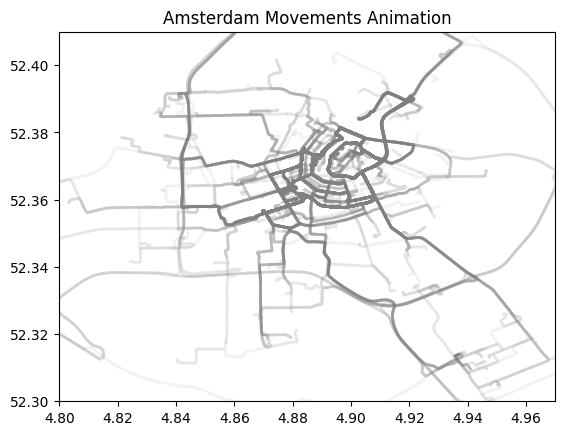

In [60]:
#df = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_from_hotel_full.csv")

#df = df.loc[0:1000, :]

# Create a new column 'movement_line' with the LineString geometry (coordinates as (longitude, latitude))
#df['movement_line'] = df.apply(lambda row: LineString([(row['longitude_hotel'], row['latitude_hotel']), (row['longitude_visited'], row['latitude_visited'])]), axis=1)
df = locations_df
# Set the number of interpolation points for the animation
num_points = 100

# Precompute interpolation points for each line
all_x_coords = []
all_y_coords = []
for idx, row in df.iterrows():
    line = row['route']
    distances = np.linspace(0, line.length, num_points)
    points = [line.interpolate(distance) for distance in distances]
    x_coords = [point.x for point in points]
    y_coords = [point.y for point in points]
    all_x_coords.append(x_coords)
    all_y_coords.append(y_coords)

# Determine plot limits based on all points
min_longitude = min(df['longitude_hotel'].min(), df['longitude_visited'].min())
max_longitude = max(df['longitude_hotel'].max(), df['longitude_visited'].max())
min_latitude = min(df['latitude_hotel'].min(), df['latitude_visited'].min())
max_latitude = max(df['latitude_hotel'].max(), df['latitude_visited'].max())

# Setup the figure and axes
fig, ax = plt.subplots()
ax.set_title("Amsterdam Movements Animation")
ax.set_xlim(4.8, 4.97)
ax.set_ylim(52.3, 52.41)

# Create a grey line plot for each movement line with transparency (alpha=0.5)
line_plots = []
for _ in range(len(df)):
    (lp,) = ax.plot([], [], color='grey', lw=2, alpha=0.1)
    line_plots.append(lp)

def init():
    for lp in line_plots:
        lp.set_data([], [])
    return line_plots

def update(frame):
    artists = []
    for i in range(len(df)):
        x_coords = all_x_coords[i]
        y_coords = all_y_coords[i]
        # Update the drawn path: slice the coordinate lists up to the current frame
        current_x = x_coords[:frame+1]
        current_y = y_coords[:frame+1]
        line_plots[i].set_data(current_x, current_y)
        artists.append(line_plots[i])
    return artists

# Create the animation; frames are from 0 to num_points-1
ani = FuncAnimation(fig, update, frames=range(num_points),
                    init_func=init, blit=True, interval=50)

# Save the animation as a GIF (requires Pillow installed)
#ani.save('multiple_movements_animation.gif', writer='pillow', fps=30)
ani.save('move_animation_route.mp4', writer='ffmpeg', fps=30)
plt.show()

In [37]:
df = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_from_hotel_full.csv")

df['movement_line'] = df.apply(
    lambda row: LineString([
        (row['longitude_hotel'], row['latitude_hotel']),
        (row['longitude_visited'], row['latitude_visited'])
    ]),
    axis=1
)

In [10]:
df = df[["place_id_hotel", "place_name_hotel", "latitude_hotel", "longitude_hotel", "place_id_visited", "place_name_visited", "latitude_visited", 
         "longitude_visited", "movement_line"]]

In [11]:
# Group by hotel and visited place, and count visits for each combination
visit_counts = df.groupby(['place_id_hotel', 'place_id_visited']).size().reset_index(name='visit_count')

# Calculate total visits from each hotel
total_visits = df.groupby('place_id_hotel').size().reset_index(name='total_visits')

# Merge the two DataFrames
visit_counts = pd.merge(visit_counts, total_visits, on='place_id_hotel')

# Compute the percentage of visits from each hotel to each visited place
visit_counts['percentage'] = (visit_counts['visit_count'] / visit_counts['total_visits']) * 100


In [12]:
move = df.drop_duplicates(subset = "movement_line")

In [13]:
move = move.merge(visit_counts, on = ["place_id_hotel", "place_id_visited"], how = "left")

In [14]:
move = move[["place_id_visited", "place_name_visited", "latitude_visited", "longitude_visited", "place_id_hotel", "latitude_hotel", "longitude_hotel", "movement_line", "percentage"]]

In [15]:
pres = pres[["place_id", "name", "Day", "Hour","pressure"]]

In [16]:
move = move.merge(pres, left_on = "place_id_visited", right_on = "place_id", how = "inner")
move["move_pressure"] = move["pressure"]*move["percentage"]
test = move[move["move_pressure"]>1]

In [17]:
test

,place_id_visited,place_name_visited,latitude_visited,longitude_visited,place_id_hotel,latitude_hotel,longitude_hotel,movement_line,percentage,place_id,name,Day,Hour,pressure,move_pressure
301,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,52.368827,4.884062,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8840617 52....",0.092421,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Saturday,13,12.734145,1.176908
302,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,52.368827,4.884062,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8840617 52....",0.092421,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Saturday,14,15.049444,1.390891
303,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,52.368827,4.884062,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8840617 52....",0.092421,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Saturday,15,16.537850,1.528452
304,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,52.368827,4.884062,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8840617 52....",0.092421,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Saturday,16,16.372472,1.513167
305,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,52.368827,4.884062,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8840617 52....",0.092421,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Saturday,17,14.884065,1.375607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39122371,ChIJG9c0F-kJxkcR0Yd6ANByMLE,The Pantry,52.363484,4.884943,ChIJzVN3QY_hxUcREIzfWnT4u94,52.341766,4.824797,"LINESTRING (4.824796699999999 52.3417663, 4.88...",0.154730,ChIJG9c0F-kJxkcR0Yd6ANByMLE,The Pantry,Saturday,19,9.647536,1.492766
39122372,ChIJG9c0F-kJxkcR0Yd6ANByMLE,The Pantry,52.363484,4.884943,ChIJzVN3QY_hxUcREIzfWnT4u94,52.341766,4.824797,"LINESTRING (4.824796699999999 52.3417663, 4.88...",0.154730,ChIJG9c0F-kJxkcR0Yd6ANByMLE,The Pantry,Saturday,20,9.551061,1.477839
39122373,ChIJG9c0F-kJxkcR0Yd6ANByMLE,The Pantry,52.363484,4.884943,ChIJzVN3QY_hxUcREIzfWnT4u94,52.341766,4.824797,"LINESTRING (4.824796699999999 52.3417663, 4.88...",0.154730,ChIJG9c0F-kJxkcR0Yd6ANByMLE,The Pantry,Saturday,21,8.200406,1.268851
39122395,ChIJG9c0F-kJxkcR0Yd6ANByMLE,The Pantry,52.363484,4.884943,ChIJzVN3QY_hxUcREIzfWnT4u94,52.341766,4.824797,"LINESTRING (4.824796699999999 52.3417663, 4.88...",0.154730,ChIJG9c0F-kJxkcR0Yd6ANByMLE,The Pantry,Sunday,19,6.946226,1.074792


In [33]:
df[["place_id_hotel", "latitude_hotel", "longitude_hotel", "place_id_visited", "latitude_visited", "longitude_visited"]]

,place_id_hotel,latitude_hotel,longitude_hotel,place_id_visited,latitude_visited,longitude_visited
0,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,ChIJKYyxKekJxkcRLAhtiEY8skw,52.362162,4.883806
1,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,ChIJg8bf-sIJxkcR9mc7li6y48E,52.369279,4.884023
2,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,ChIJg8bf-sIJxkcR9mc7li6y48E,52.369279,4.884023
3,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,ChIJd_yDtNAJxkcRko3UnBeygWA,52.370469,4.883942
4,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,ChIJrftMriIJxkcRmsYdm9XycFA,52.368827,4.884062
...,...,...,...,...,...,...
881551,ChIJzVN3QY_hxUcREIzfWnT4u94,52.341766,4.824797,ChIJX1rTlu8JxkcRGsV8-a4oKMI,52.358076,4.881205
881552,ChIJzVN3QY_hxUcREIzfWnT4u94,52.341766,4.824797,ChIJKzDpZ-UJxkcR6tvKHK2aPOw,52.358011,4.879755
881553,ChIJzVN3QY_hxUcREIzfWnT4u94,52.341766,4.824797,ChIJs-qtwfwJxkcR4-6lQTbCXw0,52.355639,4.870725
881554,ChIJzVN3QY_hxUcREIzfWnT4u94,52.341766,4.824797,ChIJS4P1Hb4JxkcRIphGLOfikzU,52.366458,4.900025


In [48]:
# Define a reference date for a given week
reference_monday = datetime.datetime(2024, 1, 1)  # Adjust to the first Monday of the year or any reference Monday

# Create a mapping from day names to a date in the reference week
day_mapping = {day: reference_monday + datetime.timedelta(days=i) for i, day in enumerate([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])}

# Sample DataFrame (assuming it's already loaded)
test['datetime'] = test.apply(lambda row: day_mapping[row['Day']] + datetime.timedelta(hours=row['Hour']), axis=1)


C:\Users\isamu\AppData\Local\Temp\ipykernel_20128\2230904549.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['datetime'] = test.apply(lambda row: day_mapping[row['Day']] + datetime.timedelta(hours=row['Hour']), axis=1)


In [58]:
locations_df = test[test["datetime"] == datetime.datetime(2024, 1, 6, 20)]
locations_df = locations_df[locations_df["move_pressure"] > 20]

,place_id_visited,place_name_visited,latitude_visited,longitude_visited,place_id_hotel,latitude_hotel,longitude_hotel,movement_line,percentage,place_id,name,Day,Hour,pressure,move_pressure,datetime
16628,ChIJz3y0xeIJxkcRNcogBVV41Gw,Vondelpark,52.357995,4.868648,ChIJ7QhSkOYJxkcRYWNXnzHjdfc,52.362842,4.876453,"LINESTRING (4.8764528 52.3628421, 4.8686484 52...",3.736572,ChIJz3y0xeIJxkcRNcogBVV41Gw,Vondelpark,Saturday,20,18.613715,69.551480,2024-01-06 20:00:00
30212,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,52.375218,4.883977,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8839765 52....",0.924214,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,Saturday,20,22.472291,20.769215,2024-01-06 20:00:00
80012,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,52.375218,4.883977,ChIJDY8OYsMJxkcRNqaKHHoTNFQ,52.373038,4.883389,"LINESTRING (4.8833892 52.373038, 4.8839765 52....",2.073733,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,Saturday,20,22.472291,46.601525,2024-01-06 20:00:00
82028,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,52.375218,4.883977,ChIJYywUslnixUcRsOW0m48buCs,52.387270,4.834320,"LINESTRING (4.83432 52.38727, 4.8839765 52.375...",2.396617,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,Saturday,20,22.472291,53.857464,2024-01-06 20:00:00
85340,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,52.375218,4.883977,ChIJR9g2f8EJxkcRqGKXxXdSric,52.369720,4.888920,"LINESTRING (4.88892 52.36972, 4.8839765 52.375...",3.277687,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,Saturday,20,22.472291,73.657142,2024-01-06 20:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38725460,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,52.375218,4.883977,ChIJD_s76eQJxkcRuiYL4hg6WW4,52.358385,4.875431,"LINESTRING (4.8754309 52.3583852, 4.8839765 52...",1.302932,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Anne Frank Huis,Saturday,20,22.472291,29.279858,2024-01-06 20:00:00
38727788,ChIJweXO1ugJxkcR2nckxDGWbIc,Hard Rock Cafe,52.362059,4.882991,ChIJD_s76eQJxkcRuiYL4hg6WW4,52.358385,4.875431,"LINESTRING (4.8754309 52.3583852, 4.8829907 52...",1.628664,ChIJweXO1ugJxkcR2nckxDGWbIc,Hard Rock Cafe,Saturday,20,15.232363,24.808409,2024-01-06 20:00:00
38739188,ChIJz3y0xeIJxkcRNcogBVV41Gw,Vondelpark,52.357995,4.868648,ChIJk2Y3ZwMJxkcRkMfesX71U2g,52.365143,4.880504,"LINESTRING (4.8805043 52.3651428, 4.8686484 52...",2.857143,ChIJz3y0xeIJxkcRNcogBVV41Gw,Vondelpark,Saturday,20,18.613715,53.182042,2024-01-06 20:00:00
38739860,ChIJmxhLHeAJxkcRKe_rH1Kqv_M,De Hallen Amsterdam,52.366845,4.868769,ChIJk2Y3ZwMJxkcRkMfesX71U2g,52.365143,4.880504,"LINESTRING (4.8805043 52.3651428, 4.8687692999...",2.857143,ChIJmxhLHeAJxkcRKe_rH1Kqv_M,De Hallen Amsterdam,Saturday,20,7.078441,20.224117,2024-01-06 20:00:00


In [78]:
locations_df_1_12 = test[test["datetime"] == datetime.datetime(2024, 1, 1, 12)]
locations_df_1_20 = test[test["datetime"] == datetime.datetime(2024, 1, 1, 20)]
locations_df_6_12 = test[test["datetime"] == datetime.datetime(2024, 1, 6, 12)]
locations_df_6_20 = test[test["datetime"] == datetime.datetime(2024, 1, 6, 20)]
locations_df = pd.concat([locations_df_1_12, locations_df_1_20, locations_df_6_12, locations_df_6_20])
locations_df = locations_df.drop_duplicates("movement_line")
locations_df = locations_df[locations_df["move_pressure"] > 2]
locations_df

,place_id_visited,place_name_visited,latitude_visited,longitude_visited,place_id_hotel,latitude_hotel,longitude_hotel,movement_line,percentage,place_id,name,Day,Hour,pressure,move_pressure,datetime
1020,ChIJAUBsos8JxkcRwnuLcQmb2-M,Winkel 43,52.379094,4.886284,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8862844 52....",0.415896,ChIJAUBsos8JxkcRwnuLcQmb2-M,Winkel 43,Monday,12,14.447295,6.008579,2024-01-01 12:00:00
2196,ChIJAUBsos8JxkcRwnuLcQmb2-M,Winkel 43,52.379094,4.886284,ChIJRy2BEJUJxkcRMVdwHVMS0r0,52.364768,4.896945,"LINESTRING (4.896945 52.364768, 4.8862844 52.3...",0.325851,ChIJAUBsos8JxkcRwnuLcQmb2-M,Winkel 43,Monday,12,14.447295,4.707663,2024-01-01 12:00:00
2700,ChIJGTWpP8cJxkcRPgLGybsqgJI,de Bijenkorf Amsterdam,52.373618,4.894502,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.894502 52.3...",0.554529,ChIJGTWpP8cJxkcRPgLGybsqgJI,de Bijenkorf Amsterdam,Monday,12,4.641177,2.573666,2024-01-01 12:00:00
4548,ChIJD7P9IsMJxkcRMrf54OxoZSg,De 9 Straatjes,52.370197,4.886051,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8860511 52....",1.987061,ChIJD7P9IsMJxkcRMrf54OxoZSg,De 9 Straatjes,Monday,12,6.168942,12.258063,2024-01-01 12:00:00
5052,ChIJYQCs26EJxkcRPUqKm3hTaA4,ARTIS,52.366000,4.916532,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.9165321 52....",0.462107,ChIJYQCs26EJxkcRPUqKm3hTaA4,ARTIS,Monday,12,11.138080,5.146987,2024-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38455940,ChIJJVNbSZcLxkcRmlFDljhOFgE,Ziggo Dome,52.313591,4.937120,ChIJ8aIni3zjxUcRHLo3kPu7aGg,52.362638,4.835280,"LINESTRING (4.8352803 52.362638, 4.9371203 52....",0.236128,ChIJJVNbSZcLxkcRmlFDljhOFgE,Ziggo Dome,Saturday,20,25.894864,6.114490,2024-01-06 20:00:00
38739524,ChIJkxQLT-kJxkcRL84p6aY2lGA,Mayur Indian/Indiaas Restaurant,52.362355,4.886161,ChIJk2Y3ZwMJxkcRkMfesX71U2g,52.365143,4.880504,"LINESTRING (4.8805043 52.3651428, 4.886161 52....",2.857143,ChIJkxQLT-kJxkcRL84p6aY2lGA,Mayur Indian/Indiaas Restaurant,Saturday,20,0.752508,2.150022,2024-01-06 20:00:00
38840036,ChIJJVNbSZcLxkcRmlFDljhOFgE,Ziggo Dome,52.313591,4.937120,ChIJk8fjEWALxkcRvcAfXF2Ker0,52.337501,4.867976,"LINESTRING (4.8679763 52.3375007, 4.9371203 52...",0.272480,ChIJJVNbSZcLxkcRmlFDljhOFgE,Ziggo Dome,Saturday,20,25.894864,7.055821,2024-01-06 20:00:00
38996276,ChIJU-SBHbkJxkcRSSxkfBFf3hw,Red Light Secrets,52.373693,4.898917,ChIJC_KvV9jhxUcRgDzDAbDHkBw,52.317434,4.856647,"LINESTRING (4.8566474 52.317434, 4.89891679999...",0.284091,ChIJU-SBHbkJxkcRSSxkfBFf3hw,Red Light Secrets,Saturday,20,7.827660,2.223767,2024-01-06 20:00:00


In [102]:
cate = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/quick_categorized.csv")
cate = cate[["place_id", "category"]]

locations_df = locations_df.merge(cate, left_on = "place_id_visited", right_on = "place_id", how = "inner")

In [79]:
import requests
import pandas as pd
from shapely.geometry import LineString



def get_osrm_route(row, profile = "foot"):
    # Extract the coordinates and note the order: (longitude, latitude)
    start_lon, start_lat = row['longitude_hotel'], row['latitude_hotel']
    end_lon, end_lat = row['longitude_visited'], row['latitude_visited']
    
    # Build the OSRM API URL with the desired profile.
    url = f"http://router.project-osrm.org/route/v1/{profile}/{start_lon},{start_lat};{end_lon},{end_lat}?overview=full&geometries=geojson"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        try:
            # Extract the list of coordinates from the GeoJSON response.
            route_coords = data['routes'][0]['geometry']['coordinates']
            # Convert the coordinates list into a Shapely LineString.
            return LineString(route_coords)
        except (IndexError, KeyError):
            return None  # No route found or unexpected response structure.
    else:
        return None  # API call failed.

# Apply the function to each row in the DataFrame.
locations_df['route'] = locations_df.apply(get_osrm_route, axis=1)

new_routes = locations_df

In [91]:
locations_df_1_12 = test[test["datetime"] == datetime.datetime(2024, 1, 1, 12)]
locations_df_1_20 = test[test["datetime"] == datetime.datetime(2024, 1, 1, 20)]
locations_df_6_12 = test[test["datetime"] == datetime.datetime(2024, 1, 6, 12)]
locations_df_6_20 = test[test["datetime"] == datetime.datetime(2024, 1, 6, 20)]
alll = pd.concat([locations_df_1_12, locations_df_1_20, locations_df_6_12, locations_df_6_20])
alll = alll[alll["move_pressure"] > 2]

In [93]:
df_route = new_routes[["movement_line", "route"]]
alll = alll.merge(df_route, on = "movement_line")

In [83]:
locations_df

,place_id_visited,place_name_visited,latitude_visited,longitude_visited,place_id_hotel,latitude_hotel,longitude_hotel,movement_line,percentage,place_id,name,Day,Hour,pressure,move_pressure,datetime,route
1020,ChIJAUBsos8JxkcRwnuLcQmb2-M,Winkel 43,52.379094,4.886284,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8862844 52....",0.415896,ChIJAUBsos8JxkcRwnuLcQmb2-M,Winkel 43,Monday,12,14.447295,6.008579,2024-01-01 12:00:00,"LINESTRING (4.884319 52.369356, 4.884313 52.36..."
2196,ChIJAUBsos8JxkcRwnuLcQmb2-M,Winkel 43,52.379094,4.886284,ChIJRy2BEJUJxkcRMVdwHVMS0r0,52.364768,4.896945,"LINESTRING (4.896945 52.364768, 4.8862844 52.3...",0.325851,ChIJAUBsos8JxkcRwnuLcQmb2-M,Winkel 43,Monday,12,14.447295,4.707663,2024-01-01 12:00:00,"LINESTRING (4.896931 52.364795, 4.897807 52.36..."
2700,ChIJGTWpP8cJxkcRPgLGybsqgJI,de Bijenkorf Amsterdam,52.373618,4.894502,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.894502 52.3...",0.554529,ChIJGTWpP8cJxkcRPgLGybsqgJI,de Bijenkorf Amsterdam,Monday,12,4.641177,2.573666,2024-01-01 12:00:00,"LINESTRING (4.884319 52.369356, 4.884313 52.36..."
4548,ChIJD7P9IsMJxkcRMrf54OxoZSg,De 9 Straatjes,52.370197,4.886051,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.8860511 52....",1.987061,ChIJD7P9IsMJxkcRMrf54OxoZSg,De 9 Straatjes,Monday,12,6.168942,12.258063,2024-01-01 12:00:00,"LINESTRING (4.884319 52.369356, 4.884313 52.36..."
5052,ChIJYQCs26EJxkcRPUqKm3hTaA4,ARTIS,52.366000,4.916532,ChIJg8bf-sIJxkcRsvcYZBHfZ14,52.369359,4.884211,"LINESTRING (4.8842114 52.369359, 4.9165321 52....",0.462107,ChIJYQCs26EJxkcRPUqKm3hTaA4,ARTIS,Monday,12,11.138080,5.146987,2024-01-01 12:00:00,"LINESTRING (4.884319 52.369356, 4.884313 52.36..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38455940,ChIJJVNbSZcLxkcRmlFDljhOFgE,Ziggo Dome,52.313591,4.937120,ChIJ8aIni3zjxUcRHLo3kPu7aGg,52.362638,4.835280,"LINESTRING (4.8352803 52.362638, 4.9371203 52....",0.236128,ChIJJVNbSZcLxkcRmlFDljhOFgE,Ziggo Dome,Saturday,20,25.894864,6.114490,2024-01-06 20:00:00,"LINESTRING (4.835275 52.362804, 4.834885 52.36..."
38739524,ChIJkxQLT-kJxkcRL84p6aY2lGA,Mayur Indian/Indiaas Restaurant,52.362355,4.886161,ChIJk2Y3ZwMJxkcRkMfesX71U2g,52.365143,4.880504,"LINESTRING (4.8805043 52.3651428, 4.886161 52....",2.857143,ChIJkxQLT-kJxkcRL84p6aY2lGA,Mayur Indian/Indiaas Restaurant,Saturday,20,0.752508,2.150022,2024-01-06 20:00:00,"LINESTRING (4.88048 52.365169, 4.880363 52.365..."
38840036,ChIJJVNbSZcLxkcRmlFDljhOFgE,Ziggo Dome,52.313591,4.937120,ChIJk8fjEWALxkcRvcAfXF2Ker0,52.337501,4.867976,"LINESTRING (4.8679763 52.3375007, 4.9371203 52...",0.272480,ChIJJVNbSZcLxkcRmlFDljhOFgE,Ziggo Dome,Saturday,20,25.894864,7.055821,2024-01-06 20:00:00,"LINESTRING (4.868626 52.337517, 4.86864 52.337..."
38996276,ChIJU-SBHbkJxkcRSSxkfBFf3hw,Red Light Secrets,52.373693,4.898917,ChIJC_KvV9jhxUcRgDzDAbDHkBw,52.317434,4.856647,"LINESTRING (4.8566474 52.317434, 4.89891679999...",0.284091,ChIJU-SBHbkJxkcRSSxkfBFf3hw,Red Light Secrets,Saturday,20,7.827660,2.223767,2024-01-06 20:00:00,"LINESTRING (4.857124 52.317413, 4.857191 52.31..."


In [13]:
#lines.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_lines.csv")

Report Lines

In [5]:
df = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_from_hotel_full.csv")
hotels = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Amsterdam/hotelbed_hotel.csv", index_col = 0)
cat = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/places_categorised.csv", index_col = 0)[["place_id", "category"]]

In [6]:
# Create a new column 'movement_line' containing the LineString connecting the two points.
df['movement_line'] = df.apply(
    lambda row: LineString([
        (row['longitude_hotel'], row['latitude_hotel']),
        (row['longitude_visited'], row['latitude_visited'])
    ]),
    axis=1
)

In [37]:
df_hotels = df.merge(hotels, left_on = "place_id_hotel", right_on = "place_id", how = "inner")
df_hotels = df_hotels[df_hotels["hotelbeds hotel"] > 0]
df_hotels = df_hotels.merge(cat, left_on = "place_id_visited", right_on = "place_id", how = "inner")
df_hotels = df_hotels[["place_id_hotel", "place_name_hotel", "place_id_visited", "place_name_visited", "reviews 2024" ,"movement_line", "category"]]

In [55]:
grp_df_hotels = df_hotels.groupby(["place_id_hotel", "place_id_visited"]).size().reset_index(name = "visits")
grp_df_hotels = grp_df_hotels.merge(df_hotels, on = ["place_id_hotel", "place_id_visited"], how = "inner")

In [61]:
grp_df_hotels.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/clean_movement_hotels.csv")

In [89]:
grp_df_hotels["category"].unique()

array(['Dining & Cafes', 'Activities', 'Shopping', 'Cannabisshop',
       'Green Recreation', 'Cultural & Historic', 'Conference',
       'Event venue', 'Entertainment & Nightlife', 'Hotel'], dtype=object)

In [90]:
grp_df_hotels

,place_id_hotel,place_id_visited,visits,place_name_hotel,place_name_visited,reviews 2024,movement_line,category
0,ChIJ-1hUL74JxkcRnLpTBTbfH5o,ChIJ--5Ki5UJxkcRaVIVCb2RSX8,18,Eden Hotel Amsterdam,Kooi Coffeeshop,522,"LINESTRING (4.8986899 52.3668376, 4.8994313 52...",Dining & Cafes
1,ChIJ-1hUL74JxkcRnLpTBTbfH5o,ChIJ--5Ki5UJxkcRaVIVCb2RSX8,18,Eden Hotel Amsterdam,Kooi Coffeeshop,522,"LINESTRING (4.8986899 52.3668376, 4.8994313 52...",Dining & Cafes
2,ChIJ-1hUL74JxkcRnLpTBTbfH5o,ChIJ--5Ki5UJxkcRaVIVCb2RSX8,18,Eden Hotel Amsterdam,Kooi Coffeeshop,522,"LINESTRING (4.8986899 52.3668376, 4.8994313 52...",Dining & Cafes
3,ChIJ-1hUL74JxkcRnLpTBTbfH5o,ChIJ--5Ki5UJxkcRaVIVCb2RSX8,18,Eden Hotel Amsterdam,Kooi Coffeeshop,522,"LINESTRING (4.8986899 52.3668376, 4.8994313 52...",Dining & Cafes
4,ChIJ-1hUL74JxkcRnLpTBTbfH5o,ChIJ--5Ki5UJxkcRaVIVCb2RSX8,18,Eden Hotel Amsterdam,Kooi Coffeeshop,522,"LINESTRING (4.8986899 52.3668376, 4.8994313 52...",Dining & Cafes
...,...,...,...,...,...,...,...,...
750701,ChIJzeKdC8AJxkcR01jCuc6AJfw,ChIJzccHg74JxkcRufHICkn86wo,1,Hotel Residence Le Coin,De Sluyswacht,47,"LINESTRING (4.8943866 52.3678912, 4.9017167 52...",Dining & Cafes
750702,ChIJzeKdC8AJxkcR01jCuc6AJfw,ChIJzwzS5owJxkcRDZfCjur-OPU,1,Hotel Residence Le Coin,Sinne,47,"LINESTRING (4.8943866 52.3678912, 4.8940709999...",Dining & Cafes
750703,ChIJzeKdC8AJxkcR01jCuc6AJfw,ChIJzx7F4r8JxkcRpWLr0JLTA8s,3,Hotel Residence Le Coin,Coffeeshop Family First,47,"LINESTRING (4.8943866 52.3678912, 4.8953932 52...",Cannabisshop
750704,ChIJzeKdC8AJxkcR01jCuc6AJfw,ChIJzx7F4r8JxkcRpWLr0JLTA8s,3,Hotel Residence Le Coin,Coffeeshop Family First,47,"LINESTRING (4.8943866 52.3678912, 4.8953932 52...",Cannabisshop


In [81]:
hotels = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Amsterdam/hotelbed_hotel.csv", index_col = 0)[["place_id", "hotelbeds hotel"]]
hotels

,place_id,hotelbeds hotel
0,ChIJbeLDaSIKxkcR4uMOfG8J_cw,1233.0
1,ChIJZyc7C7oJxkcRSPqsBgyVa0k,1240.0
2,ChIJgYCiu5kLxkcRPQIZ1Wezozs,1061.0
3,ChIJxYYOH_bixUcRmvXuhmyjUx4,1126.0
4,ChIJhfOaePYJxkcRWWJAZeXdlp4,571.0
...,...,...
386,ChIJVfi2HMgJxkcRYcxaRHoFaeo,2.0
387,ChIJyZWa5boJxkcRoi_aC8NY2AM,1.0
388,ChIJf-ETabkJxkcRnjwYhBCoeos,2.0
389,ChIJh5sG0ecJxkcRBNdP2z2Wv_o,1.0


In [74]:
df = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_from_hotel_full.csv")
cat = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/places_categorised.csv", index_col = 0)[["place_id", "category"]]
df = df.merge(cat, left_on = "place_id_visited", right_on = "place_id", how = "inner")

In [75]:
# 2. Compute per‐trip bearing (° clockwise from North)
lat1 = np.radians(df["latitude_hotel"])
lon1 = np.radians(df["longitude_hotel"])
lat2 = np.radians(df["latitude_visited"])
lon2 = np.radians(df["longitude_visited"])
dlon = lon2 - lon1

raw_bearing = np.degrees(np.arctan2(
    np.sin(dlon) * np.cos(lat2),
    np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
))
df["bearing"] = (raw_bearing + 360) % 360

# 3. Convert to unit‐vector components
df["bx"] = np.cos(np.radians(df["bearing"]))
df["by"] = np.sin(np.radians(df["bearing"]))

# 4. Group by hotel AND visited category
grouped = (
    df
    .groupby(
        ["place_id_hotel",
         "place_name_hotel",
         "latitude_hotel",
         "longitude_hotel",
         "category"],
        as_index=False
    )
    .agg({
        "bx": "sum",
        "by": "sum",
        "bearing": "count"   # just to get trip counts per group
    })
    .rename(columns={"bearing": "num_trips"})
)

# 5. Compute mean bearing per hotel‐category
mean_raw = np.degrees(np.arctan2(grouped["by"], grouped["bx"]))
grouped["mean_bearing"] = (mean_raw + 360) % 360

# 6. Final table: one row per hotel × category, with
#    latitude_hotel, longitude_hotel, main_category_visited,
#    num_trips, and mean_bearing
print(grouped[[
    "place_name_hotel",
    "category",
    "latitude_hotel",
    "longitude_hotel",
    "num_trips",
    "mean_bearing"
]])

             place_name_hotel                   category  latitude_hotel  \
0        Eden Hotel Amsterdam                 Activities       52.366838   
1        Eden Hotel Amsterdam               Cannabisshop       52.366838   
2        Eden Hotel Amsterdam                 Conference       52.366838   
3        Eden Hotel Amsterdam        Cultural & Historic       52.366838   
4        Eden Hotel Amsterdam             Dining & Cafes       52.366838   
...                       ...                        ...             ...   
3871  Hotel Residence Le Coin  Entertainment & Nightlife       52.367891   
3872  Hotel Residence Le Coin                Event venue       52.367891   
3873  Hotel Residence Le Coin           Green Recreation       52.367891   
3874  Hotel Residence Le Coin                      Hotel       52.367891   
3875  Hotel Residence Le Coin                   Shopping       52.367891   

      longitude_hotel  num_trips  mean_bearing  
0            4.898690         41    25

In [87]:
grouped = grouped.merge(hotels, left_on = "place_id_hotel", right_on = "place_id", how = "inner")

In [88]:
grouped.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/direction_hotels.csv")